In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import rasterio
import re
import tifffile
from keras.models import load_model
from keras.preprocessing.image import img_to_array



In [ ]:
# landsat 7 images -> used interpolation technique

In [2]:
import os
import re
import numpy as np
import rasterio
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import scipy.ndimage as ndimage

size = 256
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / (
        (np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    image = image / 255.0
    return image

def fill_gaps_with_interpolation(band):
    if np.ma.isMaskedArray(band):
        band = band.filled(np.nan)
    mask = np.isnan(band)
    filled_band = ndimage.generic_filter(band, np.nanmean, size=3)
    band[mask] = filled_band[mask]
    return band

def calculate_deforestation_per_year(image_paths, tile_size=size):
    deforestation_percentages = []
    forest_percentages = []

    for image_path in image_paths:
        tiles = preprocess_image(image_path, tile_size)
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()) * 100
            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages

def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))
        print(f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%")
        print(f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%")

def extract_year_from_filename(filename):
    match = re.search(r'\d{4}', filename)
    return int(match.group()) if match else None

def preprocess_image(image_path, tile_size=size):
    with rasterio.open(image_path) as src:
        red = fill_gaps_with_interpolation(src.read(1, masked=True))
        green = fill_gaps_with_interpolation(src.read(2, masked=True))
        blue = fill_gaps_with_interpolation(src.read(3, masked=True))

    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    rgb_std = np.dstack((r_std, g_std, b_std))
    rgb_std = np.clip(rgb_std, 0, 1)
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y + tile_size, x:x + tile_size, :]
            tiles.append(tile)

    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Directory of normalized Landsat images (one per year)
image_directory = "testimage/tang/landsat_7_interpolation"
image_paths = [os.path.join(image_directory, f) for f in os.listdir(image_directory) if f.endswith(".tif")]

# Run deforestation analysis
visualize_deforestation(image_paths)


C:\Users\Firoz\anaconda3\lib\site-packages\scipy\ndimage\_filters.py:1633: RuntimeWarning: Mean of empty slice
  _nd_image.generic_filter(input, function, footprint, output, mode,


1/1 [==============================] - 0s 258ms/step


1/1 [==============================] - 0s 330ms/step


1/1 [==============================] - 0s 342ms/step
Non-Forest Percentage - 2006: 78.82%
Remaining Forest Percentage - 2006: 21.18%
Non-Forest Percentage - 2007: 78.58%
Remaining Forest Percentage - 2007: 21.42%
Non-Forest Percentage - 2008: 78.54%
Remaining Forest Percentage - 2008: 21.46%
Non-Forest Percentage - 2009: 77.81%
Remaining Forest Percentage - 2009: 22.19%
Non-Forest Percentage - 2010: 78.50%
Remaining Forest Percentage - 2010: 21.50%
Non-Forest Percentage - 2011: 78.49%
Remaining Forest Percentage - 2011: 21.51%
Non-Forest Percentage - 2012: 77.56%
Remaining Forest Percentage - 2012: 22.44%


In [ ]:
# landsat 8 images normalized 

In [3]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/tang/landsat_8_normalized/2013-2023"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 0s 318ms/step


1/1 [==============================] - 0s 368ms/step


1/1 [==============================] - 0s 347ms/step


1/1 [==============================] - 0s 327ms/step
Non-Forest Percentage - 2013: 79.93%
Remaining Forest Percentage - 2013: 20.07%
Non-Forest Percentage - 2014: 81.22%
Remaining Forest Percentage - 2014: 18.78%
Non-Forest Percentage - 2015: 81.83%
Remaining Forest Percentage - 2015: 18.17%
Non-Forest Percentage - 2016: 80.89%
Remaining Forest Percentage - 2016: 19.11%
Non-Forest Percentage - 2017: 81.29%
Remaining Forest Percentage - 2017: 18.71%
Non-Forest Percentage - 2018: 80.75%
Remaining Forest Percentage - 2018: 19.25%
Non-Forest Percentage - 2019: 81.31%
Remaining Forest Percentage - 2019: 18.69%
Non-Forest Percentage - 2020: 81.04%
Remaining Forest Percentage - 2020: 18.96%
Non-Forest Percentage - 2021: 81.19%
Remaining Forest Percentage - 2021: 18.81%
Non-Forest Percentage - 2022: 81.13%
Remaining Forest Percentage - 2022: 18.87%
Non-Forest Percentage - 2023: 81.09%
Remaining Forest Percentage - 2023: 18.91%


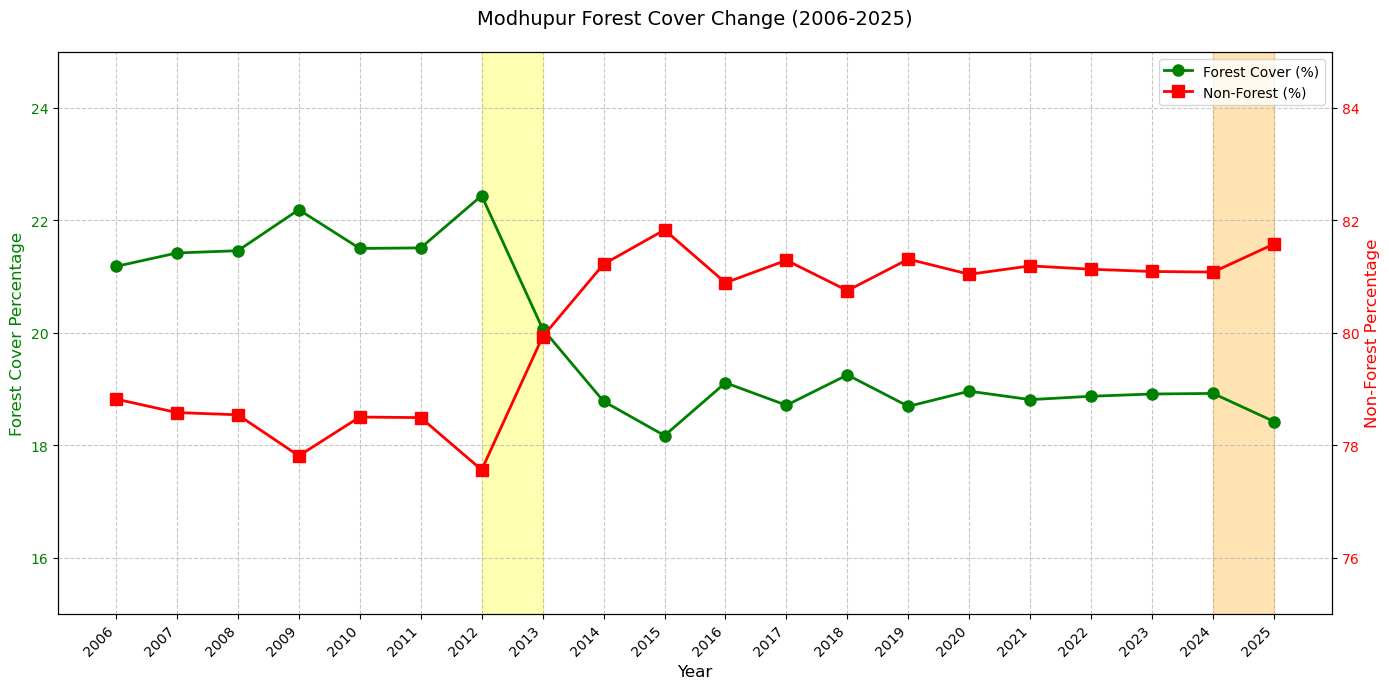

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
years = np.arange(2006, 2026)
non_forest = np.array([
    78.82, 78.58, 78.54, 77.81, 78.50, 78.49, 77.56,
    79.93, 81.22, 81.83, 80.89, 81.29, 80.75,
    81.31, 81.04, 81.19, 81.13, 81.09, 81.08, 81.58
])
forest = np.array([
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42
])

# Create figure with dual y-axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Forest cover (left axis)
ax1.plot(years, forest, 'g-o', linewidth=2, markersize=8, label='Forest Cover (%)')
ax1.set_ylabel('Forest Cover Percentage', color='g', fontsize=12)
ax1.tick_params(axis='y', labelcolor='g')
ax1.set_ylim(15, 25)  # Adjusted to show detail

# Non-forest (right axis)
ax2 = ax1.twinx()
ax2.plot(years, non_forest, 'r-s', linewidth=2, markersize=8, label='Non-Forest (%)')
ax2.set_ylabel('Non-Forest Percentage', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(75, 85)  # Mirrors forest scale

# Formatting
ax1.set_title('Modhupur Forest Cover Change (2006-2025)', fontsize=14, pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Highlight key changes
ax1.axvspan(2012, 2013, color='yellow', alpha=0.3, label='Sharp Decline')
ax1.axvspan(2024, 2025, color='orange', alpha=0.3, label='Recent Drop')

# Grid and layout
ax1.grid(True, linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()

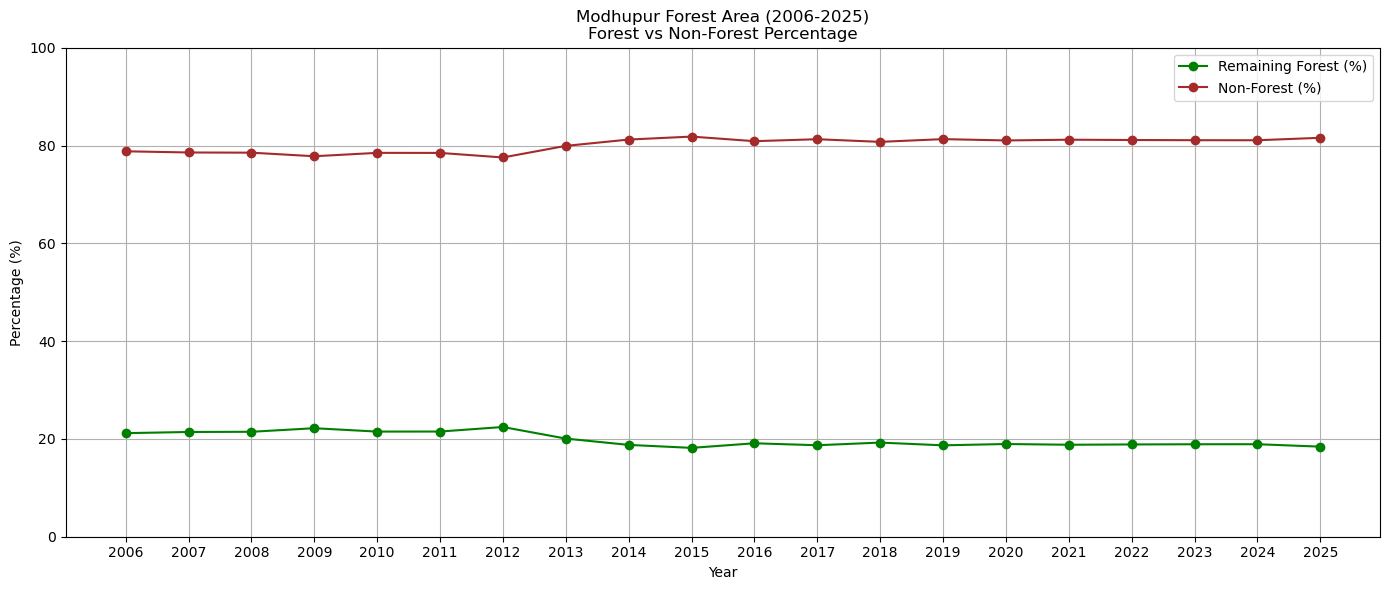

In [4]:
import matplotlib.pyplot as plt

# Data
years = list(range(2006, 2026))
forest_percentage = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25, 18.69,
    18.96, 18.81, 18.87, 18.91, 18.92, 18.42
]
non_forest_percentage = [
    78.82, 78.58, 78.54, 77.81, 78.50, 78.49, 77.56,
    79.93, 81.22, 81.83, 80.89, 81.29, 80.75, 81.31,
    81.04, 81.19, 81.13, 81.09, 81.08, 81.58
]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(years, forest_percentage, marker='o', label='Remaining Forest (%)', color='green')
plt.plot(years, non_forest_percentage, marker='o', label='Non-Forest (%)', color='brown')

plt.title('Modhupur Forest Area (2006-2025)\nForest vs Non-Forest Percentage')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.xticks(years)  # <== This will show all years on X-axis
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


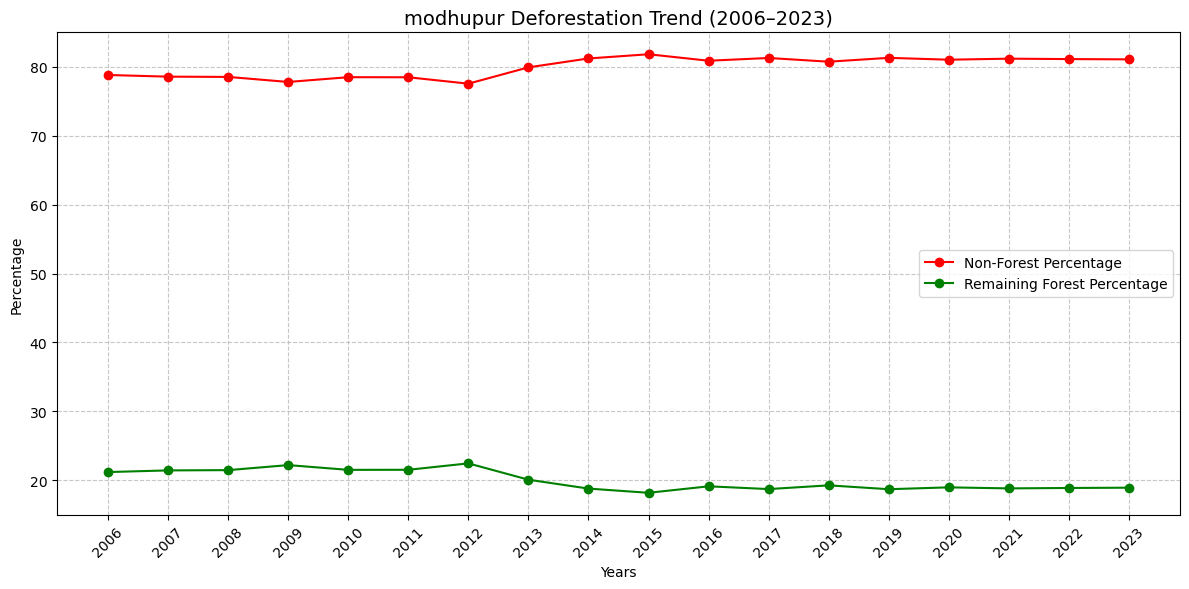

In [4]:
import matplotlib.pyplot as plt

# Years updated to match the data length
years = [
    '2006', '2007', '2008', '2009', '2010', '2011', '2012',
    '2013', '2014', '2015', '2016', '2017', '2018',
    '2019', '2020', '2021', '2022', '2023'
]

non_forest_percentages = [
    78.82, 78.58, 78.54, 77.81, 78.50, 78.49, 77.56,
    79.93, 81.22, 81.83, 80.89, 81.29, 80.75,
    81.31, 81.04, 81.19, 81.13, 81.09
]

remaining_forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91
]



# Plotting
plt.figure(figsize=(12, 6))
plt.plot(years, non_forest_percentages, marker='o', label='Non-Forest Percentage', color='red')
plt.plot(years, remaining_forest_percentages, marker='o', label='Remaining Forest Percentage', color='green')

plt.title('modhupur Deforestation Trend (2006–2023)', fontsize=14)
plt.xlabel('Years')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA paramete

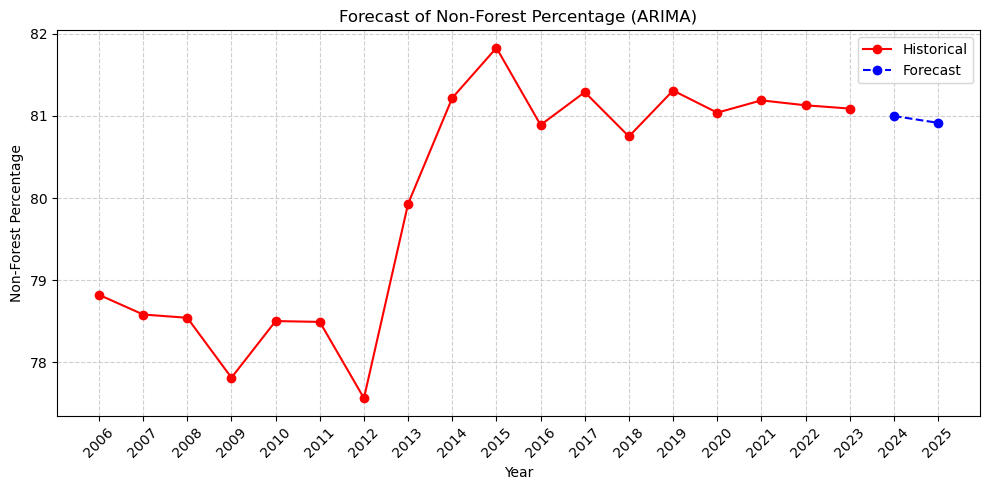

Forecasted Non-Forest Percentage for 2024: 81.00%
Forecasted Non-Forest Percentage for 2025: 80.92%


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Prepare the time series data
years = list(range(2006, 2024))
non_forest_percentages = [
    78.82, 78.58, 78.54, 77.81, 78.50, 78.49, 77.56,
    79.93, 81.22, 81.83, 80.89, 81.29, 80.75,
    81.31, 81.04, 81.19, 81.13, 81.09
]

# Convert to pandas Series
data = pd.Series(non_forest_percentages, index=pd.Index(years, name="Year"))

# Fit ARIMA model (auto order tuning can be done with pmdarima, but we manually pick for now)
model = ARIMA(data, order=(1, 1, 1))  # (p, d, q)
model_fit = model.fit()

# Forecast for next 2 years (2024 & 2025)
forecast = model_fit.forecast(steps=2)
forecast_years = [2024, 2025]

# Combine with original data for plotting
all_years = years + forecast_years
all_values = non_forest_percentages + list(forecast)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, non_forest_percentages, label="Historical", marker='o', color='red')
plt.plot(forecast_years, forecast, label="Forecast", marker='o', linestyle='--', color='blue')
plt.title("Forecast of Non-Forest Percentage (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Non-Forest Percentage")
plt.xticks(all_years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Print forecast values
for year, value in zip(forecast_years, forecast):
    print(f"Forecasted Non-Forest Percentage for {year}: {value:.2f}%")


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA paramete

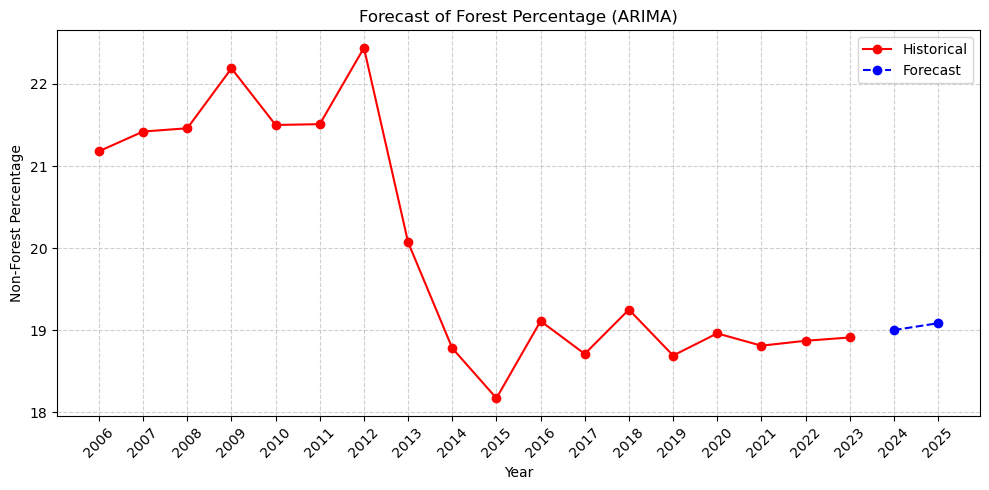

Forecasted Forest Percentage for 2024: 19.00%
Forecasted Forest Percentage for 2025: 19.08%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Prepare the time series data
years = list(range(2006, 2024))
remaining_forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91
]

# Convert to pandas Series
data = pd.Series(remaining_forest_percentages, index=pd.Index(years, name="Year"))

# Fit ARIMA model (auto order tuning can be done with pmdarima, but we manually pick for now)
model = ARIMA(data, order=(1, 1, 1))  # (p, d, q)
model_fit = model.fit()

# Forecast for next 2 years (2024 & 2025)
forecast = model_fit.forecast(steps=2)
forecast_years = [2024, 2025]

# Combine with original data for plotting
all_years = years + forecast_years
all_values = non_forest_percentages + list(forecast)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, remaining_forest_percentages, label="Historical", marker='o', color='red')
plt.plot(forecast_years, forecast, label="Forecast", marker='o', linestyle='--', color='blue')
plt.title("Forecast of Forest Percentage (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Non-Forest Percentage")
plt.xticks(all_years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Print forecast values
for year, value in zip(forecast_years, forecast):
    print(f"Forecasted Forest Percentage for {year}: {value:.2f}%")


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA paramete

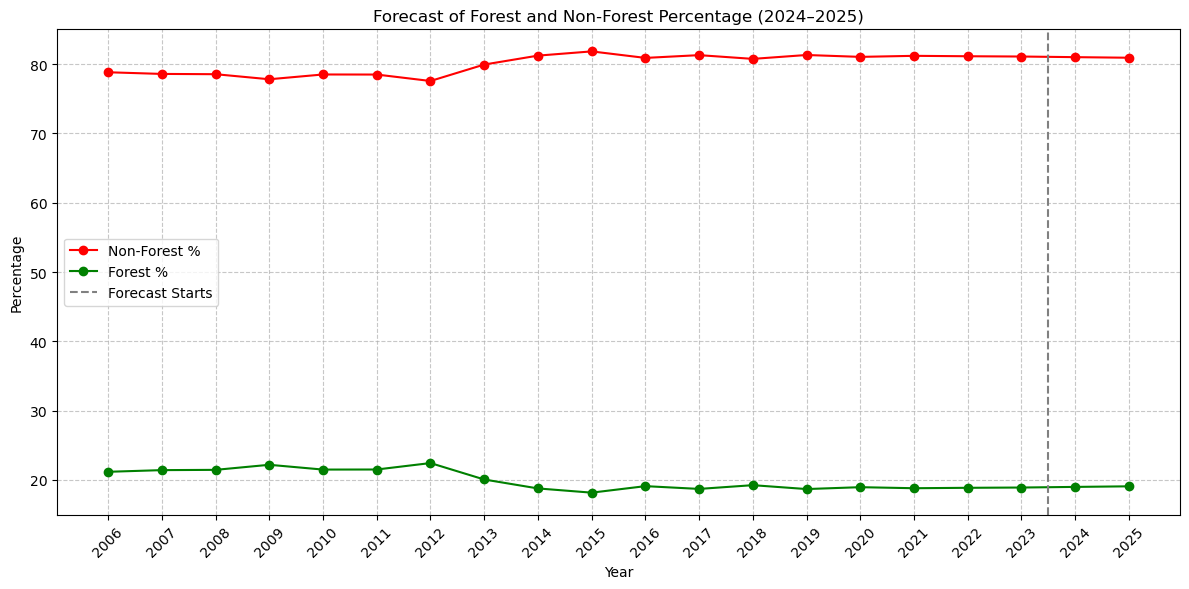

Year 2024 - Forecasted:
  Non-Forest Percentage: 81.00%
  Forest Percentage: 19.00%
Year 2025 - Forecasted:
  Non-Forest Percentage: 80.92%
  Forest Percentage: 19.08%


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Historical data
years = list(range(2006, 2024))

non_forest_percentages = [
    78.82, 78.58, 78.54, 77.81, 78.50, 78.49, 77.56,
    79.93, 81.22, 81.83, 80.89, 81.29, 80.75,
    81.31, 81.04, 81.19, 81.13, 81.09
]

# Convert to time series
data = pd.Series(non_forest_percentages, index=pd.Index(years, name="Year"))

# Fit ARIMA model
model = ARIMA(data, order=(1, 1, 1))  # You can tune this
model_fit = model.fit()

# Forecast for 2024 and 2025
forecast_steps = 2
forecast_years = [2024, 2025]
forecast_non_forest = model_fit.forecast(steps=forecast_steps)
forecast_forest = 100 - forecast_non_forest

# Combine full time series
all_years = years + forecast_years
all_non_forest = non_forest_percentages + list(forecast_non_forest)
all_forest = [100 - val for val in all_non_forest]

# Plot both
plt.figure(figsize=(12, 6))
plt.plot(all_years, all_non_forest, marker='o', label="Non-Forest %", color='red')
plt.plot(all_years, all_forest, marker='o', label="Forest %", color='green')
plt.axvline(x=2023.5, color='gray', linestyle='--', label='Forecast Starts')
plt.title("Forecast of Forest and Non-Forest Percentage (2024–2025)")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(all_years, rotation=45)
plt.tight_layout()
plt.show()

# Print forecasted values


for i in range(forecast_steps):
    print(f"Year {forecast_years[i]} - Forecasted:")
    print(f"  Non-Forest Percentage: {forecast_non_forest.iloc[i]:.2f}%")
    print(f"  Forest Percentage: {forecast_forest.iloc[i]:.2f}%")


In [9]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/tang/landsat_8_normalized/2024-2025"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 0s 320ms/step
Non-Forest Percentage - 2024: 81.08%
Remaining Forest Percentage - 2024: 18.92%
Non-Forest Percentage - 2025: 81.58%
Remaining Forest Percentage - 2025: 18.42%


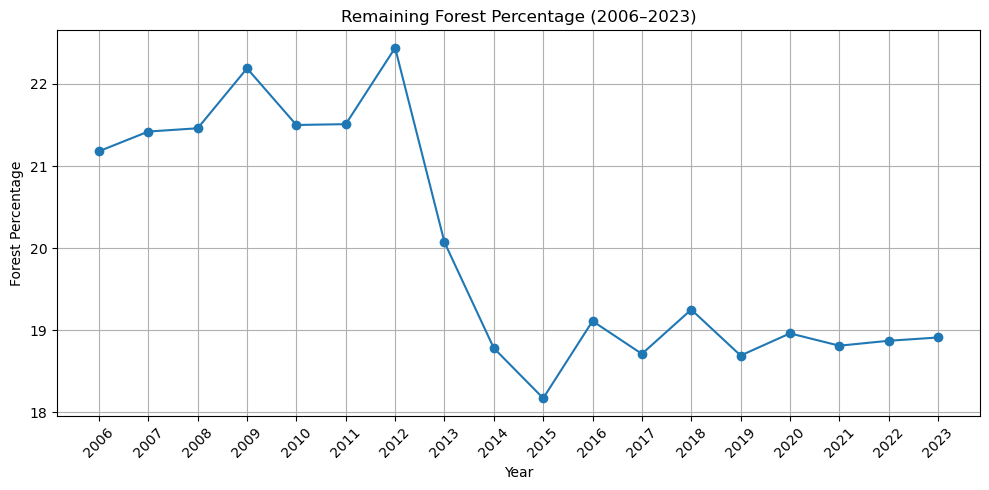

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Forest percentage data from 2006 to 2023
years = list(range(2006, 2024))
forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91
]

# Create a pandas Series
forest_series = pd.Series(forest_percentages, index=pd.Index(years, name="Year"))

# Plot with proper ticks
plt.figure(figsize=(10, 5))
forest_series.plot(title="Remaining Forest Percentage (2006–2023)", marker='o')
plt.ylabel("Forest Percentage")
plt.xticks(ticks=years, rotation=45)  # Ensure all years show
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# Fit ARIMA model (p=1, d=1, q=1) as a starting point
model = ARIMA(forest_series, order=(1, 1, 1))
model_fit = model.fit()

# Print summary of the model
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   18
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -20.569
Date:                Sun, 13 Apr 2025   AIC                             47.138
Time:                        14:10:16   BIC                             49.637
Sample:                             0   HQIC                            47.386
                                 - 18                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9183      1.795      0.511      0.609      -2.601       4.437
ma.L1         -0.9953     14.498     -0.069      0.945     -29.411      27.421
sigma2         0.6404      8.225      0.078      0.9

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA paramete

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


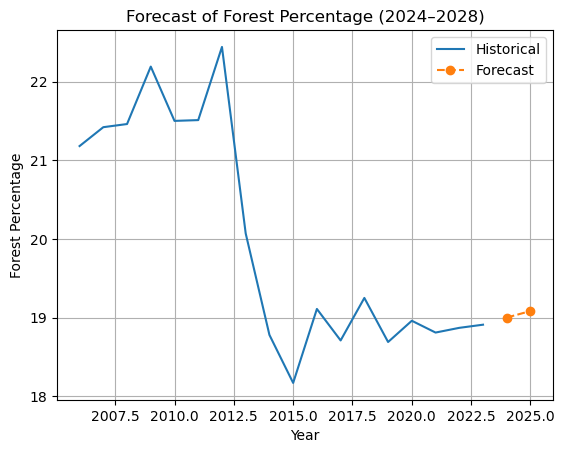

Forecast for 2024: 19.00%
Forecast for 2025: 19.08%


In [13]:
forecast = model_fit.forecast(steps=2)
forecast_years = list(range(2024, 2026))

# Plot actual and forecasted data
plt.plot(forest_series, label="Historical")
plt.plot(forecast_years, forecast, label="Forecast", marker='o', linestyle='--')
plt.title("Forecast of Forest Percentage (2024–2028)")
plt.ylabel("Forest Percentage")
plt.xlabel("Year")
plt.legend()
plt.grid(True)
plt.show()

# View forecasted values
for year, value in zip(forecast_years, forecast):
    print(f"Forecast for {year}: {value:.2f}%")


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA paramete

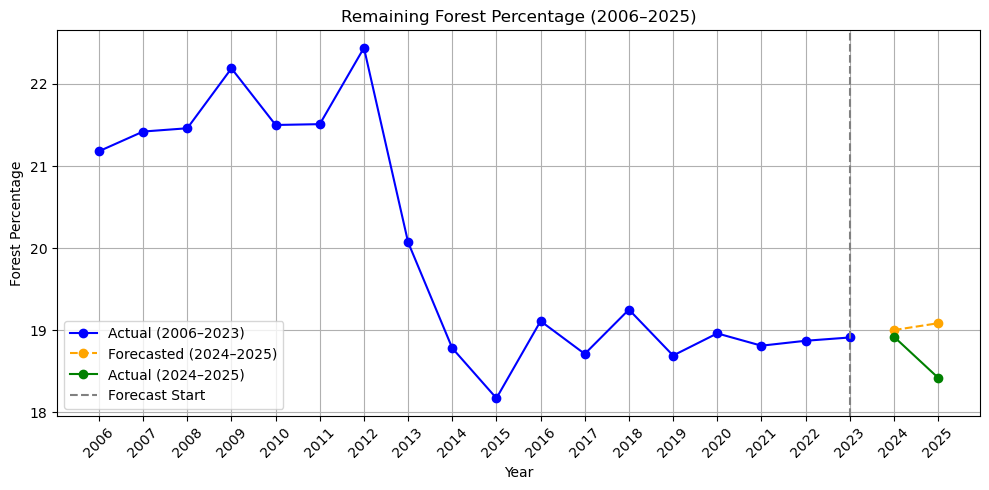

Actual vs Forecasted (2024–2025):
2024: Forecast = 19.00%, Actual = 18.92%
2025: Forecast = 19.08%, Actual = 18.42%


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Historical forest percentages (2006–2023)
years = list(range(2006, 2024))
forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91
]

# Actual values for 2024 and 2025
actual_future_years = [2024, 2025]
actual_future_values = [18.92, 18.42]

# Create series for actual historical
forest_series = pd.Series(forest_percentages, index=pd.Index(years, name="Year"))

# Fit ARIMA model and forecast for 2024, 2025
model = ARIMA(forest_series, order=(1, 1, 1))
model_fit = model.fit()
forecast_values = model_fit.forecast(steps=2)
forecast_years = [2024, 2025]
forecast_series = pd.Series(forecast_values.values, index=forecast_years)

# Combine for plotting
combined_series = pd.concat([forest_series, forecast_series])

# Plot
plt.figure(figsize=(10, 5))
plt.plot(forest_series.index, forest_series.values, marker='o', label='Actual (2006–2023)', color='blue')
plt.plot(forecast_series.index, forecast_series.values, marker='o', linestyle='--', color='orange', label='Forecasted (2024–2025)')
plt.plot(actual_future_years, actual_future_values, marker='o', linestyle='-', color='green', label='Actual (2024–2025)')

# Highlight forecast area
plt.axvline(x=2023, linestyle='--', color='gray', label='Forecast Start')

plt.title("Remaining Forest Percentage (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Forest Percentage")
plt.xticks(ticks=range(2006, 2026), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print comparison
print("Actual vs Forecasted (2024–2025):")
for year in forecast_years:
    print(f"{year}: Forecast = {forecast_series[year]:.2f}%, Actual = {actual_future_values[year - 2024]:.2f}%")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=44.894, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=46.797, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=46.781, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=43.355, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.537 seconds
Selected ARIMA order: (0, 1, 0)


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


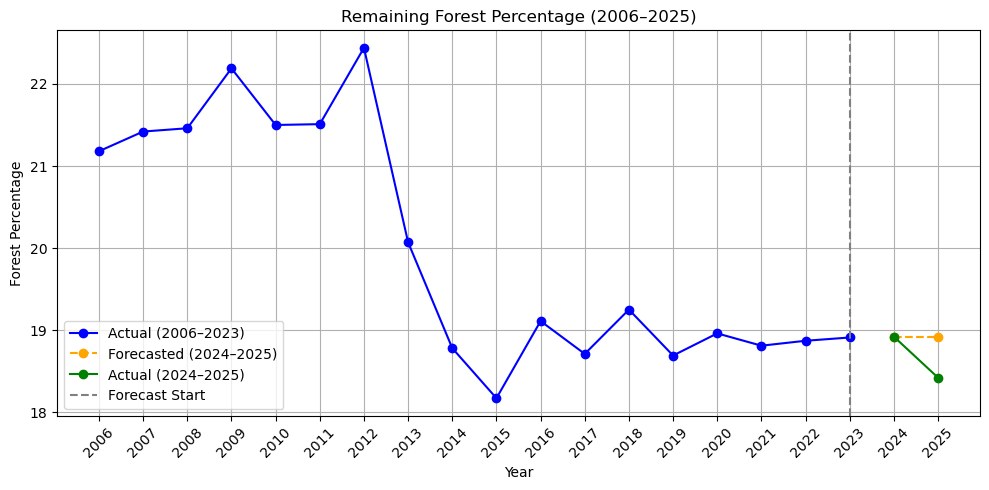


Actual vs Forecasted (2024–2025):
2024: Forecast = 18.91%, Actual = 18.92%
2025: Forecast = 18.91%, Actual = 18.42%


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Data from 2006 to 2023
years = list(range(2006, 2024))
forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91
]

# Actual values for 2024 and 2025
actual_future_years = [2024, 2025]
actual_future_values = [18.92, 18.42]

# Create series
forest_series = pd.Series(forest_percentages, index=pd.Index(years, name="Year"))

# Auto ARIMA to find best (p, d, q)
stepwise_model = auto_arima(
    forest_series, seasonal=False, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
print(f"Selected ARIMA order: {stepwise_model.order}")

# Fit best model from auto_arima
model = ARIMA(forest_series, order=stepwise_model.order)
model_fit = model.fit()
forecast = model_fit.forecast(steps=2)
forecast_years = [2024, 2025]
forecast_series = pd.Series(forecast.values, index=forecast_years)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(forest_series.index, forest_series.values, marker='o', label='Actual (2006–2023)', color='blue')
plt.plot(forecast_series.index, forecast_series.values, marker='o', linestyle='--', color='orange', label='Forecasted (2024–2025)')
plt.plot(actual_future_years, actual_future_values, marker='o', linestyle='-', color='green', label='Actual (2024–2025)')

plt.axvline(x=2023, linestyle='--', color='gray', label='Forecast Start')

plt.title("Remaining Forest Percentage (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Forest Percentage")
plt.xticks(ticks=range(2006, 2026), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print comparison
print("\nActual vs Forecasted (2024–2025):")
for year in forecast_years:
    print(f"{year}: Forecast = {forecast_series[year]:.2f}%, Actual = {actual_future_values[year - 2024]:.2f}%")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=44.894, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=46.797, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=46.781, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=43.355, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.18 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.650 seconds

Selected ARIMA order: (0, 1, 0)


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


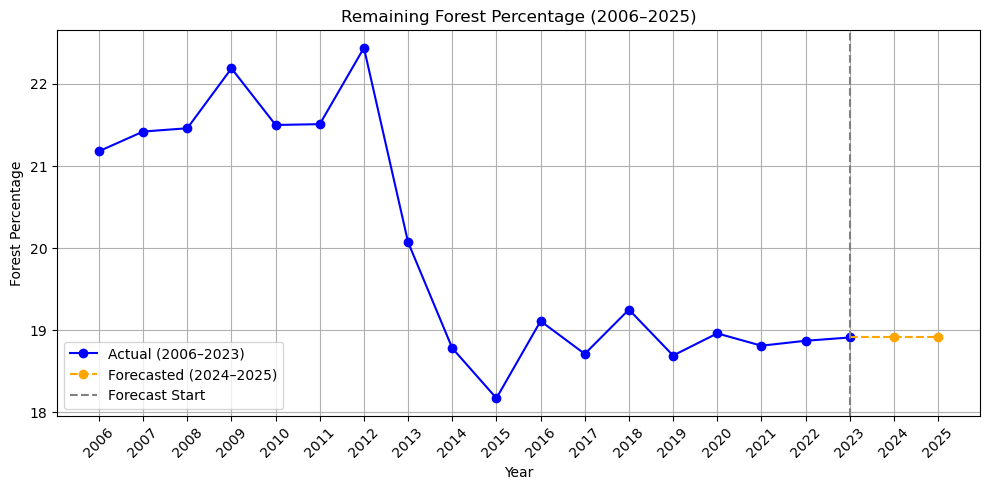


Actual vs Forecasted (2024–2025):
2024: Forecast = 18.91%, Actual = 18.92%, Difference = 0.01% (very close!)
2025: Forecast = 18.91%, Actual = 18.42%, Difference = 0.49% (a small gap)


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Forest percentage data from 2006 to 2023
years = list(range(2006, 2024))
forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91
]

# Actual values for 2024 and 2025
actual_future_years = [2024, 2025]
actual_future_values = [18.92, 18.42]

# Create pandas Series for time series modeling
forest_series = pd.Series(forest_percentages, index=pd.Index(years, name="Year"))

# Use auto_arima to find best order (p, d, q)
stepwise_model = auto_arima(
    forest_series, seasonal=False, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
print(f"\nSelected ARIMA order: {stepwise_model.order}")

# Fit ARIMA model
model = ARIMA(forest_series, order=stepwise_model.order)
model_fit = model.fit()

# Forecast for 2024 and 2025
forecast_years = [2024, 2025]
forecast = model_fit.forecast(steps=2)
forecast_series = pd.Series(forecast.values, index=forecast_years)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(forest_series.index, forest_series.values, marker='o', color='blue', label='Actual (2006–2023)')
plt.plot(forecast_series.index, forecast_series.values, marker='o', linestyle='--', color='orange', label='Forecasted (2024–2025)')

# Optional: Connect last actual (2023) to first forecast (2024)
plt.plot([2023, 2024], [forest_series[2023], forecast_series[2024]], color='orange', linestyle='--')

# Mark forecast starting point
plt.axvline(x=2023, linestyle='--', color='gray', label='Forecast Start')

plt.title("Remaining Forest Percentage (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Forest Percentage")
plt.xticks(ticks=range(2006, 2026), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print comparison
print("\nActual vs Forecasted (2024–2025):")
for i, year in enumerate(forecast_years):
    forecast_val = forecast_series[year]
    actual_val = actual_future_values[i]
    diff = abs(forecast_val - actual_val)
    comment = "very close!" if diff < 0.05 else "a small gap"
    print(f"{year}: Forecast = {forecast_val:.2f}%, Actual = {actual_val:.2f}%, Difference = {diff:.2f}% ({comment})")


Selected ARIMA order: (0, 1, 0)


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


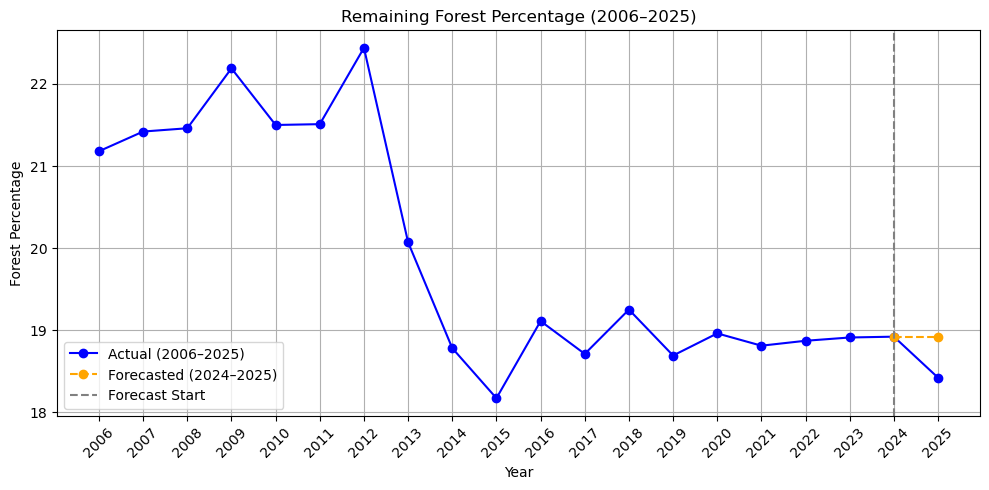


Actual vs Forecasted (2024–2025):
2024: Forecast = 18.91%, Actual = 18.92%, Difference = 0.01% (very close!)
2025: Forecast = 18.91%, Actual = 18.42%, Difference = 0.49% (a small gap)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Actual forest percentage data from 2006 to 2025
years = list(range(2006, 2026))
forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42  # includes 2024, 2025 actual
]

# Separate actual data for modeling (up to 2023)
training_years = list(range(2006, 2024))
training_data = forest_percentages[:len(training_years)]

# Fit the ARIMA model on training data
forest_series = pd.Series(training_data, index=pd.Index(training_years, name="Year"))
stepwise_model = auto_arima(
    forest_series, seasonal=False, trace=False,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
print(f"Selected ARIMA order: {stepwise_model.order}")

model = ARIMA(forest_series, order=stepwise_model.order)
model_fit = model.fit()

# Forecast for 2024 and 2025
forecast_years = [2024, 2025]
forecast = model_fit.forecast(steps=2)
forecast_series = pd.Series(forecast.values, index=forecast_years)

# Plotting both actual (including 2024–2025) and forecasted
plt.figure(figsize=(10, 5))

# Full actual data including 2024 & 2025
plt.plot(years, forest_percentages, marker='o', color='blue', label='Actual (2006–2025)')

# Forecasted values for 2024–2025
plt.plot(forecast_series.index, forecast_series.values, marker='o', linestyle='--', color='orange', label='Forecasted (2024–2025)')

# Forecast start line
plt.axvline(x=2024, linestyle='--', color='gray', label='Forecast Start')

plt.title("Remaining Forest Percentage (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Forest Percentage")
plt.xticks(ticks=range(2006, 2026), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print forecast vs actual comparison
print("\nActual vs Forecasted (2024–2025):")
actual_future_values = [18.92, 18.42]
for i, year in enumerate(forecast_years):
    forecast_val = forecast_series[year]
    actual_val = actual_future_values[i]
    diff = abs(forecast_val - actual_val)
    comment = "very close!" if diff < 0.05 else "a small gap"
    print(f"{year}: Forecast = {forecast_val:.2f}%, Actual = {actual_val:.2f}%, Difference = {diff:.2f}% ({comment})")


=== ADF Test Results ===
ADF Statistic: -1.1741
p-value: 0.9157
Critical Values:
   1%: -4.988
   5%: -3.865
   10%: -3.383

Stationary? False

=== AutoARIMA Model Selection ===
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=55.616, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.091, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=53.617, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=53.830, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=51.093, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=51.842, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,2,1)(0,0,0)[0]      

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


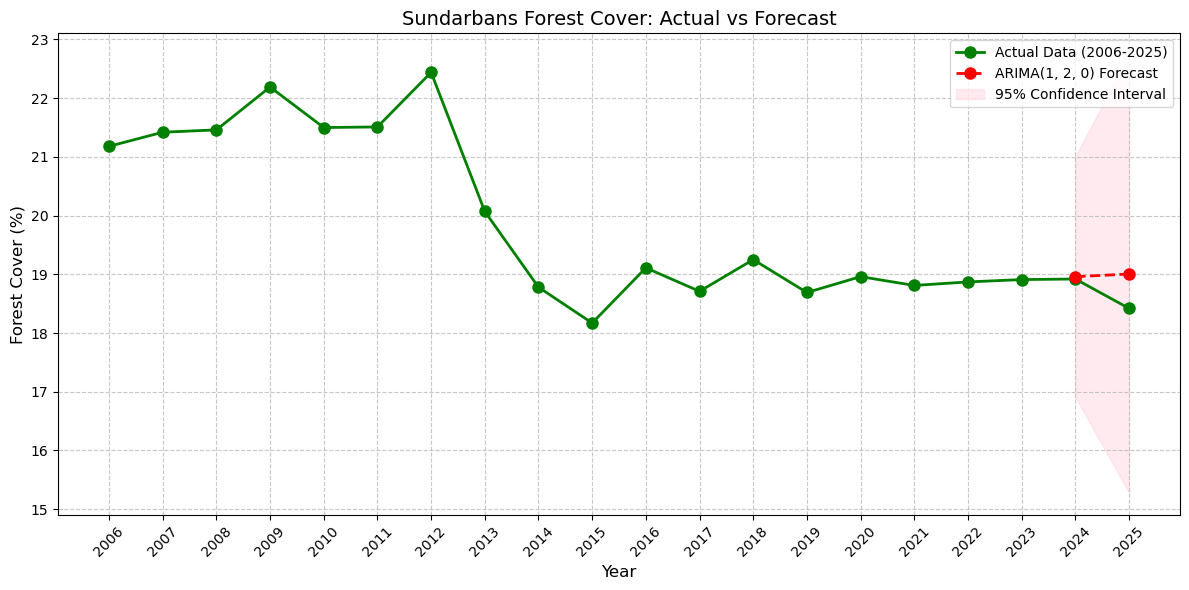

In [5]:
# Deep ARIMA Analysis for Sundarbans Forest Cover
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
years = list(range(2006, 2026))
remaining_forest = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42
]
actual_2024, actual_2025 = 18.92, 18.42

# Create complete series
full_series = pd.Series(remaining_forest, index=years)
train = full_series[:-2]  # 2006-2023
test = full_series[-2:]   # 2024-2025

# ADF Test for stationarity
def adf_test(series):
    result = adfuller(series, regression='ct')  # Using trend-aware test
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.3f}")
    return result[1] < 0.05

print("=== ADF Test Results ===")
is_stationary = adf_test(train)
print(f"\nStationary? {is_stationary}\n")

# AutoARIMA Model
print("=== AutoARIMA Model Selection ===")
model = auto_arima(train,
                  seasonal=False,
                  test='adf',
                  regression='ct',
                  stepwise=True,
                  trace=True,
                  suppress_warnings=True)

print(f"\nOptimal ARIMA Order: {model.order}")
print(f"AIC: {model.aic():.2f}")

# Forecast
forecast, conf_int = model.predict(n_periods=2, return_conf_int=True)

# Evaluation
errors = forecast - test.values
mape = np.mean(np.abs(errors/test.values))*100

# Visualization
plt.figure(figsize=(12, 6))
plt.xticks(years, rotation=45)

# Plot actual data (2006-2025)
plt.plot(full_series.index, full_series, 'go-', 
         label='Actual Data (2006-2025)', 
         linewidth=2, markersize=8)

# Plot forecast (2024-2025)
plt.plot([2024, 2025], forecast, 'ro--', 
         label=f'ARIMA{model.order} Forecast', 
         linewidth=2, markersize=8)

# Confidence interval
plt.fill_between([2024, 2025], 
                conf_int[:, 0], conf_int[:, 1],
                color='pink', alpha=0.3, 
                label='95% Confidence Interval')

plt.title('Sundarbans Forest Cover: Actual vs Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Forest Cover (%)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Results Table
results = pd.DataFrame({
    'Year': [2024, 2025],
    'Actual': test.values,
    'Forecast': forecast.round(2),
    'Lower CI': conf_int[:, 0].round(2),
    'Upper CI': conf_int[:, 1].round(2),
    'Error %': (np.abs(errors/test.values)*100).round(1)
})

print("\n=== Forecast Accuracy ===")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.1f}%")
print("\n=== Forecast vs Actual Comparison ===")
print(results.to_string(index=False))

plt.show()

=== ADF Test Results ===
ADF Statistic: -1.1741
p-value: 0.9157
Critical Values:
   1%: -4.988
   5%: -3.865
   10%: -3.383

Stationary? False

=== AutoARIMA Model Selection ===
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=55.616, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.091, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=53.617, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=53.830, Time=0.04 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=51.093, Time=0.03 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=51.842, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,2,1)(0,0,0)[0]      

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(



=== Forecast Accuracy ===
Mean Absolute Percentage Error (MAPE): 1.7%

=== Forecast vs Actual Comparison ===
 Year  Actual  Forecast  Lower CI  Upper CI  Error %
 2024   18.92     18.96     16.91     21.01      0.2
 2025   18.42     19.00     15.28     22.73      3.2


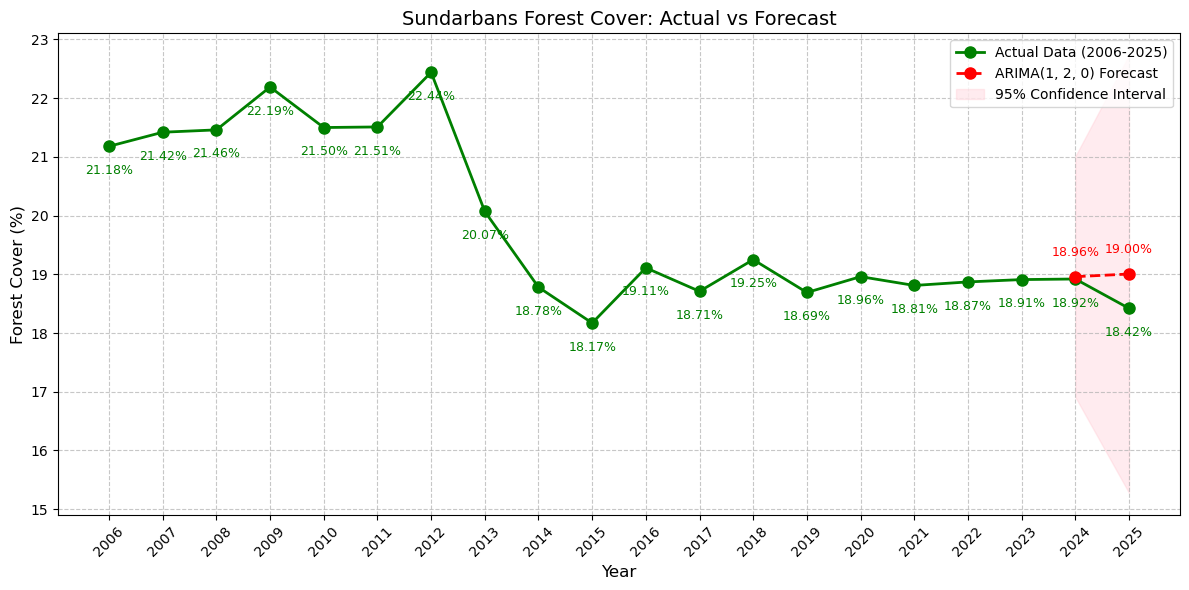

In [6]:
# Deep ARIMA Analysis for Sundarbans Forest Cover
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
years = list(range(2006, 2026))
remaining_forest = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42
]
actual_2024, actual_2025 = 18.92, 18.42

# Create complete series
full_series = pd.Series(remaining_forest, index=years)
train = full_series[:-2]  # 2006-2023
test = full_series[-2:]   # 2024-2025

# ADF Test for stationarity
def adf_test(series):
    result = adfuller(series, regression='ct')  # Using trend-aware test
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.3f}")
    return result[1] < 0.05

print("=== ADF Test Results ===")
is_stationary = adf_test(train)
print(f"\nStationary? {is_stationary}\n")

# AutoARIMA Model
print("=== AutoARIMA Model Selection ===")
model = auto_arima(train,
                  seasonal=False,
                  test='adf',
                  regression='ct',
                  stepwise=True,
                  trace=True,
                  suppress_warnings=True)

print(f"\nOptimal ARIMA Order: {model.order}")
print(f"AIC: {model.aic():.2f}")

# Forecast
forecast, conf_int = model.predict(n_periods=2, return_conf_int=True)

# Evaluation
errors = forecast - test.values
mape = np.mean(np.abs(errors/test.values))*100

# Visualization
plt.figure(figsize=(12, 6))
plt.xticks(years, rotation=45)

# Plot actual data (2006-2025)
plt.plot(full_series.index, full_series, 'go-', 
         label='Actual Data (2006-2025)', 
         linewidth=2, markersize=8)

# Add percentage labels to actual data points
for year, value in zip(full_series.index, full_series):
    plt.text(year, value-0.3, f'{value:.2f}%', 
             ha='center', va='top', color='green', fontsize=9)

# Plot forecast (2024-2025)
plt.plot([2024, 2025], forecast, 'ro--', 
         label=f'ARIMA{model.order} Forecast', 
         linewidth=2, markersize=8)

# Add percentage labels to forecast points
for year, value in zip([2024, 2025], forecast):
    plt.text(year, value+0.3, f'{value:.2f}%', 
             ha='center', va='bottom', color='red', fontsize=9)

# Confidence interval
plt.fill_between([2024, 2025], 
                conf_int[:, 0], conf_int[:, 1],
                color='pink', alpha=0.3, 
                label='95% Confidence Interval')

plt.title('Sundarbans Forest Cover: Actual vs Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Forest Cover (%)', fontsize=12)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Results Table
results = pd.DataFrame({
    'Year': [2024, 2025],
    'Actual': test.values,
    'Forecast': forecast.round(2),
    'Lower CI': conf_int[:, 0].round(2),
    'Upper CI': conf_int[:, 1].round(2),
    'Error %': (np.abs(errors/test.values)*100).round(1)
})

print("\n=== Forecast Accuracy ===")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.1f}%")
print("\n=== Forecast vs Actual Comparison ===")
print(results.to_string(index=False))

plt.show()